In [64]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt

In [65]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
ROOT_DIR

PosixPath('/Users/czyjtu/dev/prompt2avatar')

# Prepare data for trainig 

In [66]:
dataset = ProcessedDataset(DATA_DIR / 'test_geneset_embeddings')

100%|██████████| 1/1 [00:00<00:00, 76.41it/s]


## vectorize DNA

In [74]:
genes = dataset.dna
test_genes_to_predict = ["gene_forehead_brow_height.forehead_brow_height_pos", "gene_jaw_height.jaw_height_pos", "skin_color[1]"]
# get common gene set for all examples 
# sub_genes = [set(g.flatten().keys()) for g in genes]
    
# all_genes = set.union(*sub_genes)
# common_genes = set.intersection(*sub_genes)
# print(f"Number of genes in all examples: {len(all_genes)}")
# print(f"Number of common genes in all examples: {len(common_genes)}")
# common_genes

In [75]:
dataset_dna_template = create_template_from_genes(genes) # is needed to default attributes that are not present in vetorized genes

In [76]:
dataset_dna_template

{'hair_color[0]': 93,
 'hair_color[1]': 220,
 'hair_color[2]': 93,
 'hair_color[3]': 220,
 'skin_color[0]': 131,
 'skin_color[1]': 156,
 'skin_color[2]': 131,
 'skin_color[3]': 154,
 'eye_color[0]': 87,
 'eye_color[1]': 218,
 'eye_color[2]': 87,
 'eye_color[3]': 218,
 'gene_chin_forward.chin_forward_pos': 127,
 'gene_chin_height.chin_height_pos': 127,
 'gene_chin_width.chin_width_pos': 127,
 'gene_eye_angle.eye_angle_pos': 126,
 'gene_eye_depth.eye_depth_pos': 139,
 'gene_eye_height.eye_height_pos': 115,
 'gene_eye_distance.eye_distance_pos': 132,
 'gene_eye_shut.eye_shut_pos': 131,
 'gene_forehead_angle.forehead_angle_pos': 103,
 'gene_forehead_brow_height.forehead_brow_height_pos': 141,
 'gene_forehead_roundness.forehead_roundness_pos': 162,
 'gene_forehead_width.forehead_width_pos': 127,
 'gene_forehead_height.forehead_height_pos': 125,
 'gene_head_height.head_height_pos': 126,
 'gene_head_width.head_width_pos': 136,
 'gene_head_profile.head_profile_pos': 132,
 'gene_head_top_height

In [40]:
# save template 
# genes_template = Genes(**Genes.unflatten(dataset_dna_template))
# with open(ROOT_DIR / 'data' / 'mean_genes_2024_04_07.txt', 'w') as f:
#     f.write(genes_template.to_ck_string())

In [77]:
# get common gene set for all examples
genes_vectorized = [dna.asarray(list(test_genes_to_predict)) for dna in genes]
genes_vectorized = np.stack(genes_vectorized)
Y = genes_vectorized

## facial features

In [78]:
X = dataset.model2normalized_embeddings["arcface-r100"]

## train/test split

In [80]:
from sklearn.model_selection import train_test_split
# set seed for reproducibility
np.random.seed(42)
# get shuffle indiicies to use in split 
indices = np.arange(len(X))
np.random.shuffle(indices)
# get train and test indices
train_indices, test_indices = train_test_split(indices, test_size=0.1)

X_train, X_test = X[train_indices], X[test_indices]
Y_train, Y_test = Y[train_indices], Y[test_indices]

train_images = [dataset.alligned_images[i] for i in train_indices]
test_images = [dataset.alligned_images[i] for i in test_indices]

# Models

In [88]:
pd.set_option('display.max_rows', None)

def error_per_features(Y_test, Y_pred, gene_names):
    # comput rmse per feature in Y
    rmse_per_feature = np.sqrt(np.mean((Y_test - Y_pred)**2, axis=0))
    std_per_feature = np.std(Y_test, axis=0)
    tuples =  list(zip(range(len(gene_names)), sorted(gene_names), rmse_per_feature, std_per_feature))
    tuples = sorted(tuples, key=lambda x: x[2], reverse=True)
    df = pd.DataFrame(tuples, columns=["index", "gene", "rmse", "std"])
    df.set_index("index", inplace=True)
    # dipaly all rows of this df 
    return df

## XGboost

In [83]:
const_pred = np.mean(Y_train, axis=0)
np.sqrt(np.mean((Y_test - const_pred)**2))

35.226374316293956

In [84]:
# train xgboost model
import xgboost as xgb
from sklearn.metrics import mean_squared_error
evalset = [(X_train, Y_train), (X_test, Y_test)]
model = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 1, learning_rate = 0.1,
                max_depth = 8, n_estimators = 30)

model.fit(X_train, Y_train, eval_metric='rmse', eval_set=evalset, verbose=True)

Y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE: %f" % (rmse))

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:33.64490	validation_1-rmse:33.54848
[1]	validation_0-rmse:30.46060	validation_1-rmse:30.39487
[2]	validation_0-rmse:27.58795	validation_1-rmse:27.54378
[3]	validation_0-rmse:25.00756	validation_1-rmse:25.00434
[4]	validation_0-rmse:22.67947	validation_1-rmse:22.72289
[5]	validation_0-rmse:20.58729	validation_1-rmse:20.66975
[6]	validation_0-rmse:18.70545	validation_1-rmse:18.83216
[7]	validation_0-rmse:17.00343	validation_1-rmse:17.17995
[8]	validation_0-rmse:15.47882	validation_1-rmse:15.70282
[9]	validation_0-rmse:14.10945	validation_1-rmse:14.39331
[10]	validation_0-rmse:12.87640	validation_1-rmse:13.20840
[11]	validation_0-rmse:11.76014	validation_1-rmse:12.14861
[12]	validation_0-rmse:10.76292	validation_1-rmse:11.21233
[13]	validation_0-rmse:9.85769	validation_1-rmse:10.37507
[14]	validation_0-rmse:9.04553	validation_1-rmse:9.63159
[15]	validation_0-rmse:8.31895	validation_1-rmse:8.96429
[16]	validation_0-rmse:7.66265	validation_1-rmse:8.37479
[17]	validatio

In [86]:
# i = 1
# dataset_dna_template = {k: int(v) for k, v in dataset_dna_template.items()}
# with open(DATA_DIR / "tmp_dna_xgb.txt", "w") as f:
#     f.write(Genes.from_array(Y_pred[i].astype(int), list(common_genes), dataset_dna_template).to_ck_string())

# # print rmse 
# print(np.sqrt(np.mean((Y_test - Y_pred)**2)))    
# plt.imshow(test_images[i])


### most missclassified features

In [89]:


error_per_features(Y_test, Y_pred, test_genes_to_predict)

,gene,rmse,std
index,,,
2,skin_color[1],6.202323,51.883173
1,gene_jaw_height.jaw_height_pos,4.717616,12.909231
0,gene_forehead_brow_height.forehead_brow_height...,3.538108,29.360417


## Random Forest

In [90]:
# run random forest regressor 
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, max_depth=8)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print(np.sqrt(np.mean((Y_test - Y_pred)**2)))

8.999913186646197


TypeError: error_per_features() missing 1 required positional argument: 'gene_names'

In [91]:
error_per_features(Y_test, Y_pred, test_genes_to_predict)

,gene,rmse,std
index,,,
1,gene_jaw_height.jaw_height_pos,9.826511,12.909231
2,skin_color[1],9.483588,51.883173
0,gene_forehead_brow_height.forehead_brow_height...,7.516418,29.360417


## MLP

In [92]:
# scale data to -1 1 and normalize it 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# scaler_x = MinMaxScaler()
# X_train_sc = scaler_x.fit_transform(X_train)
# X_test_sc = scaler_x.transform(X_test)

scaler_y = MinMaxScaler()
Y_train_sc = scaler_y.fit_transform(Y_train)
Y_test_sc = scaler_y.transform(Y_test)

In [93]:
import torch as th 
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import EarlyStopping

class DNARegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressor, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    

class MLP(pl.LightningModule):
    def __init__(self, model: nn.Module):
        super(MLP, self).__init__()
        self.model = model 
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train_sc, dtype=torch.float32)
X_val_tensor = torch.tensor(X_test, dtype=torch.float32)
y_val_tensor = torch.tensor(Y_test_sc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


# Create PyTorch datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Initialize the model
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
model_raw = DNARegressor(input_dim, output_dim, [256])
model = MLP(model_raw)

import wandb 

with wandb.init(project="prompt2avatar", entity="czyjtu") as wandb_run:
    # Initialize Wandb logger
    wandb_logger = WandbLogger(project='prompt2avatar', entity="czyjtu", log_model=True)

    # Initialize Lightning Trainer with checkpointing and logging
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        monitor='val_loss',
        dirpath='checkpoints',
        filename='best_model',
        save_top_k=1,
        mode='min'
    )
    trainer = pl.Trainer(
        max_epochs=30,
        logger=wandb_logger,
        callbacks=[checkpoint_callback, EarlyStopping(monitor="val_loss", mode="min")],
        default_root_dir=ROOT_DIR / "training_logs",
        enable_checkpointing=True,
    )  # You can adjust max_epochs and other parameters

    # Train the model
    trainer.fit(model, train_loader, val_loader)

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:391: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:653: Checkpoint directory /Users/czyjtu/dev/prompt2avatar/notebooks/training/checkpoints exists and is not empty.

  | Name  | Type         | Params
---------------------------------------
0 | model | DNARegressor | 132 K 
---------------------------------------
132 K     Trainable params
0         Non-trainable params
132 K     Total params
0.528     Total estimated model params size (MB)


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 23: 100%|██████████| 211/211 [00:01<00:00, 122.05it/s, v_num=ovy7, train_loss_step=0.000194, val_loss=0.000233, train_loss_epoch=0.000187]


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
train_loss_epoch,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
val_loss,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,23
train_loss_epoch,0.00019
train_loss_step,0.00016
trainer/global_step,5063
val_loss,0.00023


In [94]:
# predict on test set, and inverse transform the data
model.eval()
y_pred = model(X_test_tensor).detach().numpy()
y_pred = scaler_y.inverse_transform(y_pred)
print(np.sqrt(np.mean((Y_test - y_pred)**2)))

2.2502673


In [95]:
error_per_features(Y_test, y_pred, test_genes_to_predict)

,gene,rmse,std
index,,,
2,skin_color[1],2.807925,51.883173
0,gene_forehead_brow_height.forehead_brow_height...,2.142473,29.360417
1,gene_jaw_height.jaw_height_pos,1.648175,12.909231


# brudnopis

### generate dnas with linear mutations 

In [25]:
dataset_dna_template

{'hair_color[0]': 93,
 'hair_color[1]': 220,
 'hair_color[2]': 93,
 'hair_color[3]': 220,
 'skin_color[0]': 131,
 'skin_color[1]': 154,
 'skin_color[2]': 131,
 'skin_color[3]': 154,
 'eye_color[0]': 87,
 'eye_color[1]': 218,
 'eye_color[2]': 87,
 'eye_color[3]': 218,
 'gene_chin_forward.chin_forward_pos': 127,
 'gene_chin_height.chin_height_pos': 127,
 'gene_chin_width.chin_width_pos': 127,
 'gene_eye_angle.eye_angle_pos': 126,
 'gene_eye_depth.eye_depth_pos': 139,
 'gene_eye_height.eye_height_pos': 115,
 'gene_eye_distance.eye_distance_pos': 132,
 'gene_eye_shut.eye_shut_pos': 131,
 'gene_forehead_angle.forehead_angle_pos': 103,
 'gene_forehead_brow_height.forehead_brow_height_pos': 141,
 'gene_forehead_roundness.forehead_roundness_pos': 162,
 'gene_forehead_width.forehead_width_pos': 127,
 'gene_forehead_height.forehead_height_pos': 125,
 'gene_head_height.head_height_pos': 126,
 'gene_head_width.head_width_pos': 136,
 'gene_head_profile.head_profile_pos': 132,
 'gene_head_top_height

### Create easy dna set 

In [41]:
from collections import defaultdict 
from copy import deepcopy

test_geneset = [
    'gene_forehead_brow_height',
    'gene_jaw_height',
    'skin_color[1]',
]
test_geneset_template = deepcopy(dataset_dna_template)
for gene in test_geneset:
    for k in test_geneset_template.keys():
        if gene in k:
            del test_geneset_template[k]
            print("Deleted: ", k)
            break 

Deleted:  gene_forehead_brow_height.forehead_brow_height_pos
Deleted:  gene_jaw_height.jaw_height_pos
Deleted:  skin_color[1]


In [42]:
test_geneset_dataset = []
hashes = set()
for gene in dataset.dna:
    gene_dict = gene.flatten()
    gene_dict.update(test_geneset_template)
    new_dna = Genes(**Genes.unflatten(gene_dict))
    hash_ = hash(new_dna.to_ck_string())
    if hash_ not in hashes:
        hashes.add(hash_)
        test_geneset_dataset.append(new_dna)

print(f"Length of test geneset dataset: {len(test_geneset_dataset)}")
print(f"duplicates removed: {len(dataset.dna) - len(test_geneset_dataset)}")

Length of test geneset dataset: 30332
duplicates removed: 0


In [46]:
print(len(set(X_test_geneset[:, 0])))
print(len(set(X_test_geneset[:, 1])))
print(len(set(X_test_geneset[:, 2])))


154
129
92


In [47]:
NEW_DATASET_DIR = ROOT_DIR / 'data' / 'dnas_dataset_2024_04_07_genesets' / 'test_geneset'
NEW_DATASET_DIR.mkdir(exist_ok=True, parents=True)
# for i, dna in enumerate(test_geneset_dataset[:15_000]):
#     with open(NEW_DATASET_DIR / f"{i}.txt", "w") as f:
#         f.write(dna.to_ck_string())

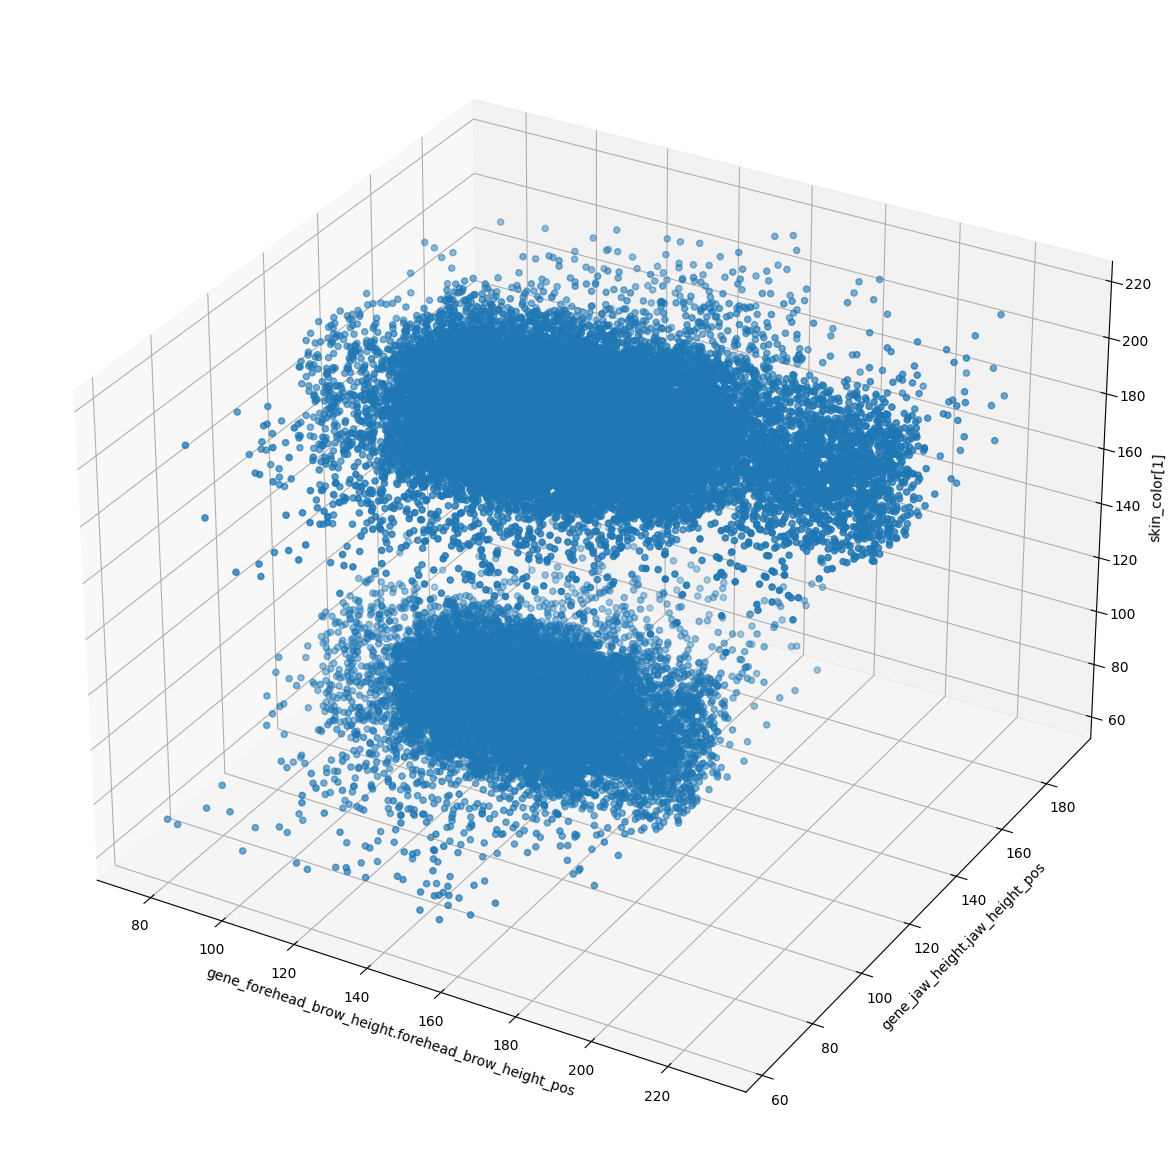

In [34]:
# display 3d distributions of the genes in the test geneset
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

test_geneset_keys = ["gene_forehead_brow_height.forehead_brow_height_pos", "gene_jaw_height.jaw_height_pos", "skin_color[1]"]
X_test_geneset = np.stack([g.asarray(test_geneset_keys) for g in test_geneset_dataset])

# display 3d distributions of the genes in the test geneset
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_test_geneset[:, 0], X_test_geneset[:, 1], X_test_geneset[:, 2])
ax.set_xlabel(test_geneset_keys[0])
ax.set_ylabel(test_geneset_keys[1])
ax.set_zlabel(test_geneset_keys[2])
plt.show()

In [15]:


gene2dnas = defaultdict(list)
for gene in common_genes:
    gene_min = -255 if gene.split(".")[0] in Genes.model_fields and Genes.model_fields[gene.split(".")[0]].annotation == dict[str, int] else 1
    for i in range(gene_min, 256, 10):
        dna = deepcopy(dataset_dna_template)
        dna[gene] = i
        gene2dnas[gene].append(dna)

In [17]:
save_dir = Path(__name__).resolve().parents[2] / 'data' / 'dnas_2024_04_07'
for gene, dnas in gene2dnas.items():
    gene_dir = save_dir / gene
    gene_dir.mkdir(exist_ok=False, parents=True)
    for i, dna in enumerate(dnas):
        ck_string = Genes(**Genes.unflatten(dna)).to_ck_string()
        dna_fname = f"{i+1}.txt"
        with open(gene_dir / dna_fname, "w") as f:
            f.write(ck_string)
    gene2dnas[gene] = dnas

In [ ]:
# dispaly hisograms for each common gene 
import matplotlib.pyplot as plt
for i, gene in enumerate(common_genes):
    plt.hist(genes_vectorized[:, i])
    plt.title(f"{gene}")
    plt.show()

In [ ]:
import random 
from collections import defaultdict

def create_template_from_genes(genes_list: list[Genes]):
    flattened_dna = [dna.flatten() for dna in genes_list]
    temmplate = defaultdict(list)
    for dna in flattened_dna:
        for key, val in dna.items():
            temmplate[key].append(val)
    avg_template = {key: int(np.mean(val)) for key, val in temmplate.items()}
    return avg_template

random.seed(40)
random.shuffle(genes)
dataset_dna_template = create_template_from_genes(genes)

In [ ]:
# get random image, and gene vector
import random 
import matplotlib.pyplot as plt 

random.seed(114) # is needed to default attributes that are not present in vetorized genes
random_idx = random.randint(0, len(test_images))
image = test_images[random_idx]
gene_vector = Y_test[random_idx]

plt.imshow(image)
plt.show()
# with open(DATA_DIR / "tmp_dna.txt", "w") as f:
#     f.write(Genes.from_array(gene_vector, list(common_genes), dataset_dna_template).to_ck_string())

In [ ]:
from utils.dataset import ProcessedDataset

dataset = ProcessedDataset(Path("/Users/czyjtu/dev/prompt2avatar/data/dataset_2024_04_07_embeddings"))

In [60]:
dataset.paths

array(['/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/0_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10000_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/10001_resized.png',
       ...,
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/999_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/99_resized.png',
       '/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_resized/9_resized.png'],
      dtype='<U114')

In [62]:
dnas = [open(path.replace("faces_resized", "dna").replace("png", "txt").replace("_resized", ""), "r").read() for path in dataset.paths]

In [63]:
# np.save("/Users/czyjtu/dev/prompt2avatar/data/test_geneset_embeddings/dnas.npy", dnas)

In [ ]:
i = 100
plt.imshow(dataset.alligned_images[i])
path = Path(dataset.paths[i])
plt.show()
plt.imshow(plt.imread("../../" + dataset.paths[i]))

In [ ]:
path.resolve()

In [55]:
import os
from PIL import Image

def resize_image(image_path, max_dimension, out_dir):
    # Open the image
    img = Image.open(image_path)
    
    # Convert the image to RGB mode
    rgb_img = img.convert("RGB")
    
    # Resize the image while preserving aspect ratio
    width, height = rgb_img.size
    if width > height:
        new_width = max_dimension
        new_height = int(height * (max_dimension / width))
    else:
        new_width = int(width * (max_dimension / height))
        new_height = max_dimension
    
    resized_img = rgb_img.resize((new_width, new_height))
    
    # Save the resized image with the same name in the same directory
    directory, filename = os.path.split(image_path)
    filename, ext = os.path.splitext(filename)
    new_filename = os.path.join(out_dir, f"{filename}_resized{ext}")
    resized_img.save(new_filename)
    # print(f"Resized image saved as: {new_filename}")

# Example usage
# image_path = DATA_DIR / "0.png"  # Replace with the path to your image
# max_dimension = 430
# resize_image(image_path, max_dimension)

In [56]:
# for path in tqdm(sorted(list(Path("/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces").rglob("*.png")))):
#     resize_image(path, 430, "/Users/czyjtu/dev/prompt2avatar/data/dnas_dataset_2024_04_07_genesets/test_geneset/faces_v2")

100%|██████████| 15000/15000 [20:22<00:00, 12.27it/s]
